# Phase 1: Pretraining Modality-Specific Autoencoders

This notebook implements Phase 1 of the MIMIR pipeline: training **independent denoising autoencoders** for each omics modality.
The goal of this phase is to learn stable, modality-specific latent representations that can later be aligned into a shared space (Phase 2).

Each autoencoder is trained using a denoising objective that explicitly masks a fraction of the input features.
These pretrained encoders serve two purposes:
1. They provide good initializations for downstream multimodal alignment.
2. They act as standalone imputers for missing values within a single modality.

Modalities covered in this notebook:
- Copy number variation (CNV)
- miRNA expression
- mRNA expression
- DNA methylation


## Setup and data loading

We begin by importing core PyTorch utilities and helper functions defined in `src/`.
All data handling, masking logic, and training loops are implemented in reusable modules to keep the notebooks lightweight and readable.

The multi-omic data are loaded from a preprocessed pickle file containing aligned samples across modalities.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
import numpy as np
import random
from typing import Dict, List, Tuple
import pickle
from torch.optim import Adam
import matplotlib.pyplot as plt
import pandas as pd
import json

In [4]:
from src.data_utils import *
from src.mae_masked import *
from src.shared_finetune import *
from src.impute import *

In [5]:
with open('tcga_redo_mlomicZ.pkl', 'rb') as f:
    multi_omic_data = pickle.load(f)

In [6]:
multi_omic_data.keys()

dict_keys(['cnv', 'miRNA', 'rna', 'methylation'])

## Shared train/validation/test splits

To ensure consistency across modalities, we load **shared sample splits** from a JSON file.
Only samples present in *all* modalities are considered.

These indices are reused across all modality-specific autoencoders so that:
- Validation metrics are comparable across modalities
- Downstream multimodal models operate on aligned splits


In [9]:
common_samples, train_idx, val_idx, test_idx = load_shared_splits_from_json(
    multi_omic_data,
    json_path='splits.json'
)
print(f"Shared N={len(common_samples)} | train={len(train_idx)} | val={len(val_idx)}| test={len(test_idx)}")

Shared N=8034 | train=6409 | val=798| test=800


In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')

In [11]:
device

device(type='cuda')

## 1. Training individual modality autoencoders

For each modality, we:
1. Construct a dataset aligned to the shared sample list
2. Define a shallow denoising autoencoder architecture
3. Train using a masked and overall reconstruction loss
4. Evaluate reconstruction quality on held-out validation samples
5. Save the trained model along with its configuration


### 1.1 Copy Number Variation (CNV)

CNV data are relatively high-dimensional.
We therefore use a simple one-hidden-layer autoencoder with moderate capacity.

In [13]:
cnv_ds = SingleModalityDatasetAligned(multi_omic_data['cnv'], common_samples)
cnv_train = get_dataloader(cnv_ds, batch_size=128, shuffle=True,  split_idx=train_idx)
cnv_val   = get_dataloader(cnv_ds, batch_size=128, shuffle=False, split_idx=val_idx)
cnv_test   = get_dataloader(cnv_ds, batch_size=128, shuffle=False, split_idx=test_idx)

In [20]:
input_dim = multi_omic_data['cnv'].shape[1]
print(input_dim)
hidden_layers = [256]  # different for different modalities

config = {
    'input_dim': input_dim,
    'hidden_layers': hidden_layers,
    'activation_dropout': 0.05,
    'denoising': True,
    'mask_p': 0.3,
    'tied': False,
    'mask_value': 0.0,      # CNV sentinel (neutral)
    'loss_on_masked': True, # track masked entries in AE
}

cnv_ae, cnv_hidden = build_pretrain_ae_for_modality(
    input_dim,
    hidden_layers,
    activation_dropout=config['activation_dropout'],
    denoising=config['denoising'],
    mask_p=config['mask_p'],
    tied=config['tied'],
    mask_value=config['mask_value'],
    loss_on_masked=config['loss_on_masked'],
)
cnv_ae = cnv_ae.to(device)

3105


In [21]:
opt = Adam(cnv_ae.parameters(), lr=1e-3, weight_decay=1e-5)

train_loss_hist = []
train_overall_hist = []
train_masked_hist = []
val_overall_hist = []
val_masked_hist = []

for ep in range(1, 60):
    tr_loss, tr_overall, tr_masked = pretrain_modality_epoch(
        cnv_ae, cnv_train, opt, device,
        l1_alpha=1e-4,
        alpha_mask=0.5,   # tweak to change balance between overall reconstruction and mask reconstruction
    )
    va_overall, va_masked = eval_modality_epoch_masked(cnv_ae, cnv_val, device)

    train_loss_hist.append(tr_loss)
    train_overall_hist.append(tr_overall)
    train_masked_hist.append(tr_masked)
    val_overall_hist.append(va_overall)
    val_masked_hist.append(va_masked)

    print(f"[Pretrain: cnv] ep {ep:03d} | loss {tr_loss:.4f} | overall {tr_overall:.4f} | masked {tr_masked:.4f} | val overall {va_overall:.4f}| val masked {va_masked:.4f}")

[Pretrain: cnv] ep 001 | loss 0.4190 | overall 0.4181 | masked 0.4198 | val overall 0.2247| val masked 0.2257
[Pretrain: cnv] ep 002 | loss 0.1870 | overall 0.1864 | masked 0.1875 | val overall 0.1573| val masked 0.1590
[Pretrain: cnv] ep 003 | loss 0.1410 | overall 0.1400 | masked 0.1418 | val overall 0.1305| val masked 0.1328
[Pretrain: cnv] ep 004 | loss 0.1200 | overall 0.1189 | masked 0.1209 | val overall 0.1147| val masked 0.1165
[Pretrain: cnv] ep 005 | loss 0.1074 | overall 0.1059 | masked 0.1088 | val overall 0.1098| val masked 0.1122
[Pretrain: cnv] ep 006 | loss 0.0995 | overall 0.0979 | masked 0.1010 | val overall 0.1015| val masked 0.1060
[Pretrain: cnv] ep 007 | loss 0.0938 | overall 0.0922 | masked 0.0953 | val overall 0.0928| val masked 0.0977
[Pretrain: cnv] ep 008 | loss 0.0865 | overall 0.0848 | masked 0.0880 | val overall 0.0876| val masked 0.0913
[Pretrain: cnv] ep 009 | loss 0.0833 | overall 0.0814 | masked 0.0850 | val overall 0.0854| val masked 0.0905
[Pretrain:

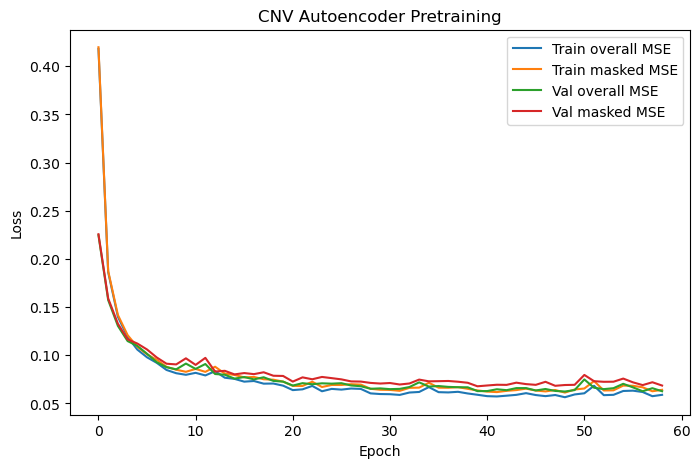

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(train_overall_hist, label="Train overall MSE")
plt.plot(train_masked_hist, label="Train masked MSE")
plt.plot(val_overall_hist, label="Val overall MSE")
plt.plot(val_masked_hist, label="Val masked MSE")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNV Autoencoder Pretraining")
plt.legend()
plt.show()

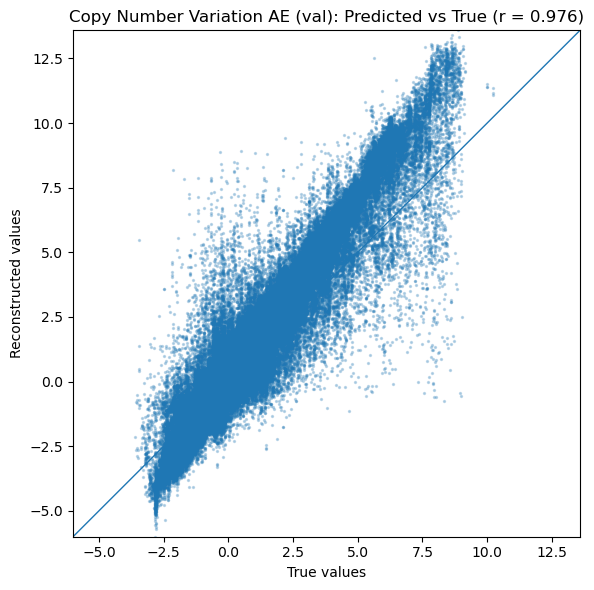

In [24]:
# === Plot predicted (reconstruction) vs. true for cnv (val split) ===
import numpy as np
import torch
import matplotlib.pyplot as plt

cnv_ae.eval()
true_vals = []
pred_vals = []

with torch.no_grad():
    for xb in cnv_val:              # uses the same met_val DataLoader you created above
        xb = xb.to(device)
        _, recon = cnv_ae(xb)
        true_vals.append(xb.cpu())
        pred_vals.append(recon.cpu())

true = torch.cat(true_vals, dim=0).flatten().numpy()
pred = torch.cat(pred_vals, dim=0).flatten().numpy()

# Remove any NaNs/Infs just in case
mask = np.isfinite(true) & np.isfinite(pred)
true = true[mask]; pred = pred[mask]

# Pearson r (fallback if scipy isn't available)
r = np.corrcoef(true, pred)[0, 1]

plt.figure(figsize=(6, 6))
plt.scatter(true, pred, s=2, alpha=0.25)
lims = [min(true.min(), pred.min()), max(true.max(), pred.max())]
plt.plot(lims, lims, linewidth=1)  # y = x reference
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("True values")
plt.ylabel("Reconstructed values")
plt.title(f"Copy Number Variation AE (val): Predicted vs True (r = {r:.3f})")
plt.tight_layout()
plt.show()

The trained CNV autoencoder is saved together with its configuration.
These checkpoints are reused in Phase 2 to initialize the multimodal shared space model.

In [26]:
save_modality_with_config(cnv_ae, config,"aes_redo_z/cnv_ae")

### 1.2 miRNA expression

miRNA profiles are lower-dimensional than CNV.
We therefore use a smaller hidden layer while keeping the same denoising strategy.


In [27]:
mir_ds = SingleModalityDatasetAligned(multi_omic_data['miRNA'], common_samples)
mir_train = get_dataloader(mir_ds, batch_size=128, shuffle=True,  split_idx=train_idx)
mir_val   = get_dataloader(mir_ds, batch_size=128, shuffle=False, split_idx=val_idx)
mir_test   = get_dataloader(mir_ds, batch_size=128, shuffle=False, split_idx=test_idx)

In [28]:
input_dim = multi_omic_data['miRNA'].shape[1]
print(input_dim)
hidden_layers = [128]

config = {
    'input_dim': input_dim,
    'hidden_layers': hidden_layers,
    'activation_dropout': 0.05,
    'denoising': True,
    'mask_p': 0.3,
    'tied': False,
    'mask_value': 0,      # mirna sentinel
    'loss_on_masked': True, # track masked entries in AE
}

mir_ae, mir_hidden = build_pretrain_ae_for_modality(
    input_dim,
    hidden_layers,
    activation_dropout=config['activation_dropout'],
    denoising=config['denoising'],
    mask_p=config['mask_p'],
    tied=config['tied'],
    mask_value=config['mask_value'],
    loss_on_masked=config['loss_on_masked'],
)
mir_ae = mir_ae.to(device)

opt = Adam(mir_ae.parameters(), lr=1e-3, weight_decay=1e-5)

train_loss_hist = []
train_overall_hist = []
train_masked_hist = []
val_overall_hist = []
val_masked_hist = []

for ep in range(1, 60):
    tr_loss, tr_overall, tr_masked = pretrain_modality_epoch(
        mir_ae, mir_train, opt, device,
        l1_alpha=1e-4,
        alpha_mask=0.5,   # care equally about reconstructing everything and just the masked values; can play with this
    )
    va_overall, va_masked = eval_modality_epoch_masked(mir_ae, mir_val, device)

    train_loss_hist.append(tr_loss)
    train_overall_hist.append(tr_overall)
    train_masked_hist.append(tr_masked)
    val_overall_hist.append(va_overall)
    val_masked_hist.append(va_masked)

    print(f"[Pretrain: cnv] ep {ep:03d} | loss {tr_loss:.4f} | overall {tr_overall:.4f} | masked {tr_masked:.4f} | val overall {va_overall:.4f}| val masked {va_masked:.4f}")

383
[Pretrain: cnv] ep 001 | loss 0.6251 | overall 0.6163 | masked 0.6339 | val overall 0.4186| val masked 0.4405
[Pretrain: cnv] ep 002 | loss 0.3651 | overall 0.3497 | masked 0.3804 | val overall 0.3214| val masked 0.3600
[Pretrain: cnv] ep 003 | loss 0.3105 | overall 0.2908 | masked 0.3301 | val overall 0.2814| val masked 0.3230
[Pretrain: cnv] ep 004 | loss 0.2841 | overall 0.2625 | masked 0.3055 | val overall 0.2592| val masked 0.3076
[Pretrain: cnv] ep 005 | loss 0.2686 | overall 0.2448 | masked 0.2923 | val overall 0.2464| val masked 0.2945
[Pretrain: cnv] ep 006 | loss 0.2565 | overall 0.2316 | masked 0.2812 | val overall 0.2344| val masked 0.2820
[Pretrain: cnv] ep 007 | loss 0.2495 | overall 0.2236 | masked 0.2753 | val overall 0.2259| val masked 0.2809
[Pretrain: cnv] ep 008 | loss 0.2446 | overall 0.2167 | masked 0.2723 | val overall 0.2209| val masked 0.2774
[Pretrain: cnv] ep 009 | loss 0.2407 | overall 0.2120 | masked 0.2692 | val overall 0.2166| val masked 0.2763
[Pretr

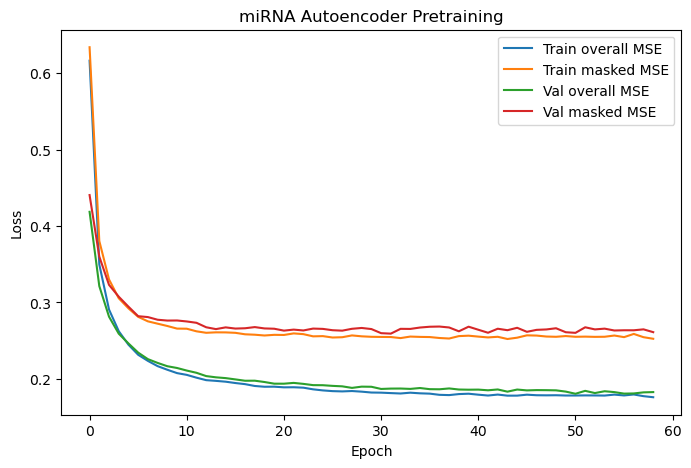

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(train_overall_hist, label="Train overall MSE")
plt.plot(train_masked_hist, label="Train masked MSE")
plt.plot(val_overall_hist, label="Val overall MSE")
plt.plot(val_masked_hist, label="Val masked MSE")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("miRNA Autoencoder Pretraining")
plt.legend()
plt.show()

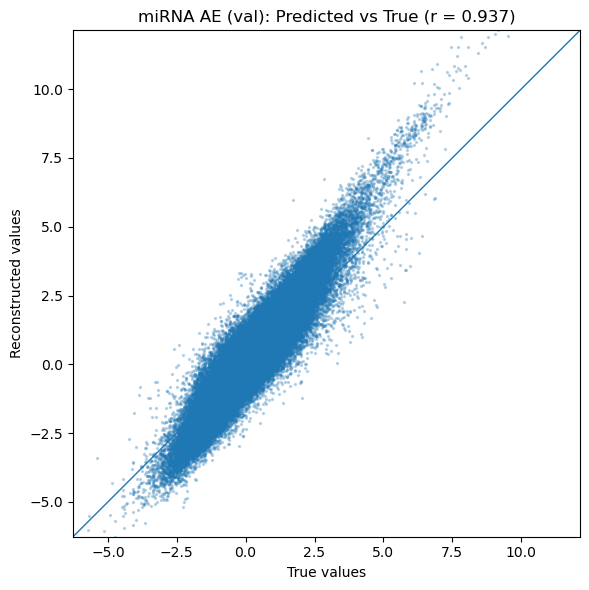

In [31]:
mir_ae.eval()
true_vals = []
pred_vals = []

with torch.no_grad():
    for xb in mir_val:              # uses the same met_test DataLoader created above
        xb = xb.to(device)
        _, recon = mir_ae(xb)
        true_vals.append(xb.cpu())
        pred_vals.append(recon.cpu())

true = torch.cat(true_vals, dim=0).flatten().numpy()
pred = torch.cat(pred_vals, dim=0).flatten().numpy()

# Remove any NaNs/Infs just in case
mask = np.isfinite(true) & np.isfinite(pred)
true = true[mask]; pred = pred[mask]

# Pearson r (fallback if scipy isn't available)
r = np.corrcoef(true, pred)[0, 1]

plt.figure(figsize=(6, 6))
plt.scatter(true, pred, s=2, alpha=0.25)
lims = [min(true.min(), pred.min()), max(true.max(), pred.max())]
plt.plot(lims, lims, linewidth=1)  # y = x reference
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("True values")
plt.ylabel("Reconstructed values")
plt.title(f"miRNA AE (val): Predicted vs True (r = {r:.3f})")
plt.tight_layout()
plt.show()

In [32]:
save_modality_with_config(mir_ae, config,"aes_redo_z/mir_ae")

### 1.3 mRNA expression

mRNA expression is the highest-dimensional modality considered here.
To accommodate this, we increase the hidden layer size to allow sufficient compression capacity.

In [34]:
rna_ds = SingleModalityDatasetAligned(multi_omic_data['rna'], common_samples)
rna_train = get_dataloader(rna_ds, batch_size=128, shuffle=True,  split_idx=train_idx)
rna_val   = get_dataloader(rna_ds, batch_size=128, shuffle=False, split_idx=val_idx)
#rna_test   = get_dataloader(rna_ds, batch_size=128, shuffle=False, split_idx=test_idx)

In [35]:
input_dim = multi_omic_data['rna'].shape[1]
print(input_dim)
hidden_layers = [512]

config = {
    'input_dim': input_dim,
    'hidden_layers': hidden_layers,
    'activation_dropout': 0.05,
    'denoising': True,
    'mask_p': 0.3,
    'tied': False,
    'mask_value': 0,      # mrna sentinel
    'loss_on_masked': True, # track masked entries in AE
}

rna_ae, rna_hidden = build_pretrain_ae_for_modality(
    input_dim,
    hidden_layers,
    activation_dropout=config['activation_dropout'],
    denoising=config['denoising'],
    mask_p=config['mask_p'],
    tied=config['tied'],
    mask_value=config['mask_value'],
    loss_on_masked=config['loss_on_masked'],
)
rna_ae = rna_ae.to(device)

opt = Adam(rna_ae.parameters(), lr=1e-3, weight_decay=1e-5)

train_loss_hist = []
train_overall_hist = []
train_masked_hist = []
val_overall_hist = []
val_masked_hist = []

for ep in range(1, 70):
    tr_loss, tr_overall, tr_masked = pretrain_modality_epoch(
        rna_ae, rna_train, opt, device,
        l1_alpha=1e-4,
        alpha_mask=0.5,   # care equally about reconstructing everything and just the masked values
    )
    va_overall, va_masked = eval_modality_epoch_masked(rna_ae, rna_val, device)

    train_loss_hist.append(tr_loss)
    train_overall_hist.append(tr_overall)
    train_masked_hist.append(tr_masked)
    val_overall_hist.append(va_overall)
    val_masked_hist.append(va_masked)

    print(f"[Pretrain: mrna] ep {ep:03d} | loss {tr_loss:.4f} | overall {tr_overall:.4f} | masked {tr_masked:.4f} | val overall {va_overall:.4f}| val masked {va_masked:.4f}")

3007
[Pretrain: mrna] ep 001 | loss 0.5127 | overall 0.5100 | masked 0.5153 | val overall 0.3979| val masked 0.4054
[Pretrain: mrna] ep 002 | loss 0.3629 | overall 0.3566 | masked 0.3690 | val overall 0.3476| val masked 0.3617
[Pretrain: mrna] ep 003 | loss 0.3305 | overall 0.3228 | masked 0.3379 | val overall 0.3287| val masked 0.3457
[Pretrain: mrna] ep 004 | loss 0.3127 | overall 0.3036 | masked 0.3217 | val overall 0.3126| val masked 0.3357
[Pretrain: mrna] ep 005 | loss 0.3016 | overall 0.2903 | masked 0.3127 | val overall 0.3029| val masked 0.3266
[Pretrain: mrna] ep 006 | loss 0.2945 | overall 0.2826 | masked 0.3063 | val overall 0.2955| val masked 0.3209
[Pretrain: mrna] ep 007 | loss 0.2887 | overall 0.2751 | masked 0.3023 | val overall 0.2907| val masked 0.3195
[Pretrain: mrna] ep 008 | loss 0.2853 | overall 0.2710 | masked 0.2995 | val overall 0.2865| val masked 0.3167
[Pretrain: mrna] ep 009 | loss 0.2812 | overall 0.2668 | masked 0.2954 | val overall 0.2851| val masked 0.3

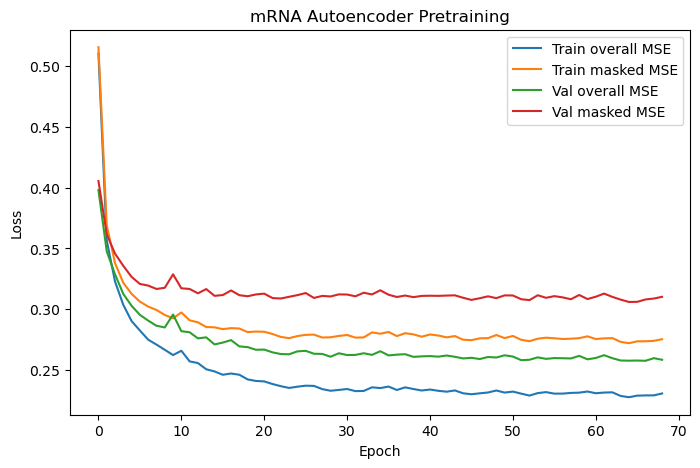

In [36]:
plt.figure(figsize=(8, 5))
plt.plot(train_overall_hist, label="Train overall MSE")
plt.plot(train_masked_hist, label="Train masked MSE")
plt.plot(val_overall_hist, label="Val overall MSE")
plt.plot(val_masked_hist, label="Val masked MSE")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("mRNA Autoencoder Pretraining")
plt.legend()
plt.show()

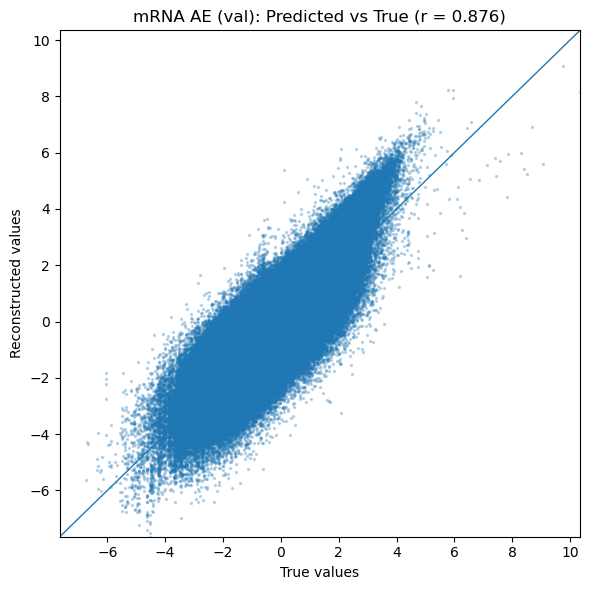

In [38]:
rna_ae.eval()
true_vals = []
pred_vals = []

with torch.no_grad():
    for xb in rna_val:              
        xb = xb.to(device)
        _, recon = rna_ae(xb)
        true_vals.append(xb.cpu())
        pred_vals.append(recon.cpu())

true = torch.cat(true_vals, dim=0).flatten().numpy()
pred = torch.cat(pred_vals, dim=0).flatten().numpy()

# Remove any NaNs/Infs just in case
mask = np.isfinite(true) & np.isfinite(pred)
true = true[mask]; pred = pred[mask]

# Pearson r (fallback if scipy isn't available)
r = np.corrcoef(true, pred)[0, 1]

plt.figure(figsize=(6, 6))
plt.scatter(true, pred, s=2, alpha=0.25)
lims = [min(true.min(), pred.min()), max(true.max(), pred.max())]
plt.plot(lims, lims, linewidth=1)  # y = x reference
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("True values")
plt.ylabel("Reconstructed values")
plt.title(f"mRNA AE (val): Predicted vs True (r = {r:.3f})")
plt.tight_layout()
plt.show()

In [39]:
save_modality_with_config(rna_ae, config, "aes_redo_z/rna_ae")

### 1.4 DNA methylation

DNA methylation profiles are high-dimensional and continuous, similar to CNV but with different biological structure.
We use an architecture comparable to CNV with identical denoising settings.


In [40]:
mth_ds = SingleModalityDatasetAligned(multi_omic_data['methylation'], common_samples)
mth_train = get_dataloader(mth_ds, batch_size=128, shuffle=True,  split_idx=train_idx)
mth_val   = get_dataloader(mth_ds, batch_size=128, shuffle=False, split_idx=val_idx)

In [41]:
input_dim = multi_omic_data['methylation'].shape[1]
print(input_dim)
hidden_layers = [256]  

config = {
    'input_dim': input_dim,
    'hidden_layers': hidden_layers,
    'activation_dropout': 0.05,
    'denoising': True,
    'mask_p': 0.3,
    'tied': False,
    'mask_value': 0.0,      # mth sentinel
    'loss_on_masked': True, # track masked entries in AE
}

mth_ae, mth_hidden = build_pretrain_ae_for_modality(
    input_dim,
    hidden_layers,
    activation_dropout=config['activation_dropout'],
    denoising=config['denoising'],
    mask_p=config['mask_p'],
    tied=config['tied'],
    mask_value=config['mask_value'],
    loss_on_masked=config['loss_on_masked'],
)
mth_ae = mth_ae.to(device)

opt = Adam(mth_ae.parameters(), lr=1e-3, weight_decay=1e-5)

train_loss_hist = []
train_overall_hist = []
train_masked_hist = []
val_overall_hist = []
val_masked_hist = []

for ep in range(1, 60):
    tr_loss, tr_overall, tr_masked = pretrain_modality_epoch(
        mth_ae, mth_train, opt, device,
        l1_alpha=1e-4,
        alpha_mask=0.5,   # care equally about reconstructing everything and just the masked values
    )
    va_overall, va_masked = eval_modality_epoch_masked(mth_ae, mth_val, device)

    train_loss_hist.append(tr_loss)
    train_overall_hist.append(tr_overall)
    train_masked_hist.append(tr_masked)
    val_overall_hist.append(va_overall)
    val_masked_hist.append(va_masked)

    print(f"[Pretrain: methylation] ep {ep:03d} | loss {tr_loss:.4f} | overall {tr_overall:.4f} | masked {tr_masked:.4f} | val overall {va_overall:.4f}| val masked {va_masked:.4f}")

3139
[Pretrain: methylation] ep 001 | loss 0.5866 | overall 0.5847 | masked 0.5883 | val overall 0.4370| val masked 0.4407
[Pretrain: methylation] ep 002 | loss 0.4021 | overall 0.3984 | masked 0.4057 | val overall 0.3820| val masked 0.3899
[Pretrain: methylation] ep 003 | loss 0.3662 | overall 0.3614 | masked 0.3709 | val overall 0.3540| val masked 0.3650
[Pretrain: methylation] ep 004 | loss 0.3466 | overall 0.3407 | masked 0.3525 | val overall 0.3418| val masked 0.3543
[Pretrain: methylation] ep 005 | loss 0.3356 | overall 0.3288 | masked 0.3422 | val overall 0.3289| val masked 0.3443
[Pretrain: methylation] ep 006 | loss 0.3254 | overall 0.3177 | masked 0.3329 | val overall 0.3271| val masked 0.3428
[Pretrain: methylation] ep 007 | loss 0.3193 | overall 0.3111 | masked 0.3274 | val overall 0.3161| val masked 0.3328
[Pretrain: methylation] ep 008 | loss 0.3144 | overall 0.3056 | masked 0.3229 | val overall 0.3147| val masked 0.3331
[Pretrain: methylation] ep 009 | loss 0.3110 | over

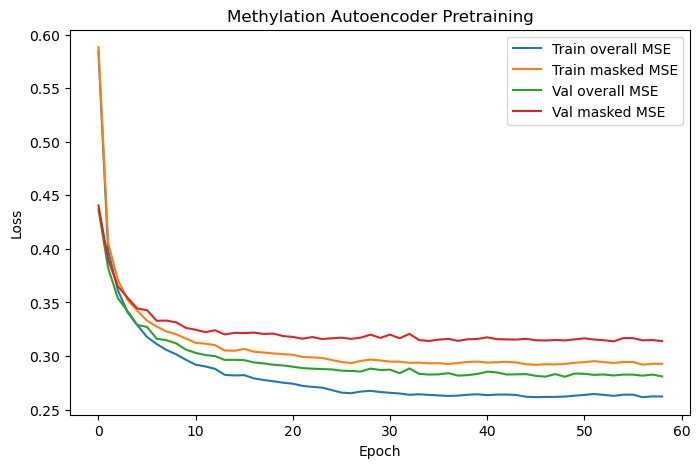

In [42]:
plt.figure(figsize=(8, 5))
plt.plot(train_overall_hist, label="Train overall MSE")
plt.plot(train_masked_hist, label="Train masked MSE")
plt.plot(val_overall_hist, label="Val overall MSE")
plt.plot(val_masked_hist, label="Val masked MSE")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Methylation Autoencoder Pretraining")
plt.legend()
plt.show()

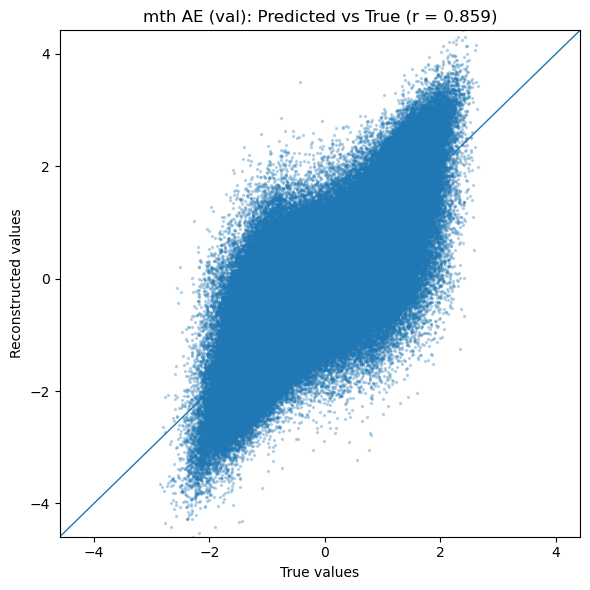

In [44]:
mth_ae.eval()
true_vals = []
pred_vals = []

with torch.no_grad():
    for xb in mth_val:              
        xb = xb.to(device)
        _, recon = mth_ae(xb)
        true_vals.append(xb.cpu())
        pred_vals.append(recon.cpu())

true = torch.cat(true_vals, dim=0).flatten().numpy()
pred = torch.cat(pred_vals, dim=0).flatten().numpy()

# Remove any NaNs/Infs just in case
mask = np.isfinite(true) & np.isfinite(pred)
true = true[mask]; pred = pred[mask]

# Pearson r (fallback if scipy isn't available)
r = np.corrcoef(true, pred)[0, 1]

plt.figure(figsize=(6, 6))
plt.scatter(true, pred, s=2, alpha=0.25)
lims = [min(true.min(), pred.min()), max(true.max(), pred.max())]
plt.plot(lims, lims, linewidth=1)  # y = x reference
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("True values")
plt.ylabel("Reconstructed values")
plt.title(f"mth AE (val): Predicted vs True (r = {r:.3f})")
plt.tight_layout()
plt.show()

In [45]:
save_modality_with_config(mth_ae, config, "aes_redo_z/mth_ae")

## Summary

In this notebook, we trained denoising autoencoders for each omics modality independently.
All models show stable convergence and strong reconstruction performance on held-out validation data.

These pretrained encoders will be used in subsequent phases to:
- Initialize modality-specific embeddings
- Enable alignment into a shared latent space
- Support multimodal imputation under arbitrary missingness patterns
